## Textile Material Classification using Convolutional Neural Networks (CNN)

### Objective

The objective of this project is to develop a Convolutional Neural Network (CNN) model that can classify textile materials from fabric images.

The trained model will be integrated into the Textile Waste Intelligence Platform to support:

- Material Classification
- Waste Categorization
- Recyclability Assessment
- Recycling Recommendations

This notebook covers the complete machine learning workflow, including:

- Dataset preparation
- Data preprocessing
- Data augmentation
- CNN model development
- Model training
- Model evaluation
- Saving the trained model for FastAPI integration

In [1]:
!pip install -q kaggle

In [ ]:
#import os

# Uncomment and fill these values if you need to download the dataset from Kaggle.
# os.environ["KAGGLE_USERNAME"] = "<YOUR_KAGGLE_USERNAME>"
# os.environ["KAGGLE_API_TOKEN"] = "<YOUR_KAGGLE_API_TOKEN>"

In [3]:
!kaggle datasets download -d orchit/the-fabrics-dataset-by-ibug --unzip

Dataset URL: https://www.kaggle.com/datasets/orchit/the-fabrics-dataset-by-ibug
License(s): unknown
100% 1.77G/1.77G [01:29<00:00, 21.3MB/s]



In [4]:
import os

print(os.listdir("/content"))

['.config', 'Cotton', 'Linen', 'Denim', 'Lut', 'Satin', 'Utilities', 'Suede', 'Polyester', 'Leather', 'Corduroy', 'Fleece', 'Silk', 'Nylon', 'Blended', 'Wool', 'Acrylic', 'Velvet', 'Models', 'Artificial_fur', 'Unclassified', 'Felt', 'Viscose', 'Chenille', 'Terrycloth', 'Artificial_leather', 'Crepe', 'sample_data']


In [5]:
for root, dirs, files in os.walk("/content"):
    if dirs:
        print(root)

/content
/content/.config
/content/.config/logs
/content/Cotton
/content/Linen
/content/Denim
/content/Lut
/content/Satin
/content/Utilities
/content/Suede
/content/Polyester
/content/Leather
/content/Corduroy
/content/Fleece
/content/Silk
/content/Nylon
/content/Blended
/content/Wool
/content/Acrylic
/content/Velvet
/content/Artificial_fur
/content/Unclassified
/content/Felt
/content/Viscose
/content/Chenille
/content/Terrycloth
/content/Artificial_leather
/content/Crepe


In [6]:
# --- Core imports ---
import os
import json
import random
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)



In [7]:
# --- Reproducibility ---
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [8]:
# --- Project Configuration ---
# Store all project settings (paths, classes, image size, training parameters)
# in one place for easy maintenance and reuse throughout the notebook.

CONFIG = {
    # Dataset paths
    "RAW_DATA_DIR": Path("/content"),
    "MODEL_OUTPUT_DIR": Path("/content/Models"),

    # Fabric classes
    "CLASS_NAMES": [
        "Cotton", "Blended", "Polyester", "Denim", "Wool",
        "Nylon", "Silk", "Viscose", "Fleece", "Terrycloth",
    ],

    # Image settings
    "IMG_SIZE": (224, 224),
    "BATCH_SIZE": 32,

    # Dataset split ratios
    "TRAIN_RATIO": 0.70,
    "VAL_RATIO": 0.15,
    "TEST_RATIO": 0.15,

    # Training settings
    "EPOCHS": 40,
    "LEARNING_RATE": 1e-3,

    # Random seed for reproducibility
    "SEED": SEED,
}

# Create the output directory if it doesn't already exist
CONFIG["MODEL_OUTPUT_DIR"].mkdir(parents=True, exist_ok=True)

In [9]:
def discover_class_folders(raw_data_dir: Path, target_classes: list) -> dict:
    """
    Find the required fabric class folders from the dataset. Returns a dictionary mapping class names to folder paths.
    """
    available = {p.name: p for p in raw_data_dir.iterdir() if p.is_dir()}
    available_lookup = {name.strip().lower(): path for name, path in available.items()}

    resolved, missing = {}, []
    for cls in target_classes:
        key = cls.strip().lower()
        if key in available_lookup:
            resolved[cls] = available_lookup[key]
        else:
            missing.append(cls)

    print(f"Resolved {len(resolved)}/{len(target_classes)} target classes.")
    if missing:
        print(f"WARNING - not found on disk: {missing}")
        print(f"Folders actually available: {sorted(available.keys())}")
    return resolved


class_dirs = discover_class_folders(CONFIG["RAW_DATA_DIR"], CONFIG["CLASS_NAMES"])
class_dirs

Resolved 10/10 target classes.


{'Cotton': PosixPath('/content/Cotton'),
 'Blended': PosixPath('/content/Blended'),
 'Polyester': PosixPath('/content/Polyester'),
 'Denim': PosixPath('/content/Denim'),
 'Wool': PosixPath('/content/Wool'),
 'Nylon': PosixPath('/content/Nylon'),
 'Silk': PosixPath('/content/Silk'),
 'Viscose': PosixPath('/content/Viscose'),
 'Fleece': PosixPath('/content/Fleece'),
 'Terrycloth': PosixPath('/content/Terrycloth')}

In [10]:
def build_swatch_index(class_dirs: dict) -> pd.DataFrame:
    """
    Create a swatch-level index containing image paths for each fabric sample.
    """
    IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
    rows = []
    for cls, cls_path in class_dirs.items():
        for swatch_path in [p for p in cls_path.iterdir() if p.is_dir()]:
            images = sorted(str(p) for p in swatch_path.iterdir() if p.suffix.lower() in IMG_EXTS)
            if not images:
                continue
            rows.append({
                "class": cls,
                "swatch_id": f"{cls}/{swatch_path.name}",
                "swatch_path": str(swatch_path),
                "n_images": len(images),
                "image_paths": images,
            })
    return pd.DataFrame(rows)


swatch_df = build_swatch_index(class_dirs)
print(f"Total swatches: {len(swatch_df)}  |  Total images: {swatch_df['n_images'].sum()}")
swatch_df.groupby("class").agg(swatches=("swatch_id", "count"), images=("n_images", "sum"))

Total swatches: 1684  |  Total images: 6737


,swatches,images
class,,
Blended,411,1645
Cotton,588,2352
Denim,162,648
Fleece,33,132
Nylon,57,228
Polyester,226,904
Silk,50,200
Terrycloth,30,120
Viscose,37,148


In [11]:
def split_swatches(swatch_df, train_ratio, val_ratio, test_ratio, seed):
    """Split the dataset into training, validation and testing sets at the swatch level."""
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6

    train_df, temp_df = train_test_split(
        swatch_df, train_size=train_ratio, stratify=swatch_df["class"], random_state=seed
    )
    relative_val_ratio = val_ratio / (val_ratio + test_ratio)
    val_df, test_df = train_test_split(
        temp_df, train_size=relative_val_ratio, stratify=temp_df["class"], random_state=seed
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


train_swatches, val_swatches, test_swatches = split_swatches(
    swatch_df, CONFIG["TRAIN_RATIO"], CONFIG["VAL_RATIO"], CONFIG["TEST_RATIO"], CONFIG["SEED"]
)
print(f"Swatches -> train: {len(train_swatches)}, val: {len(val_swatches)}, test: {len(test_swatches)}")

Swatches -> train: 1178, val: 253, test: 253


In [12]:
# --- Leakage sanity check ---
train_ids, val_ids, test_ids = set(train_swatches["swatch_id"]), set(val_swatches["swatch_id"]), set(test_swatches["swatch_id"])

assert not (train_ids & val_ids), "LEAKAGE between train/val"
assert not (train_ids & test_ids), "LEAKAGE between train/test"
assert not (val_ids & test_ids), "LEAKAGE between val/test"
print("No swatch-level leakage detected between train/val/test.")

No swatch-level leakage detected between train/val/test.


In [13]:
def expand_to_image_level(split_df: pd.DataFrame) -> pd.DataFrame:
    """Turn the swatch-level split into (filepath, label) rows for the Keras pipeline."""
    records = []
    for _, row in split_df.iterrows():
        for img_path in row["image_paths"]:
            records.append({"filepath": img_path, "class": row["class"], "swatch_id": row["swatch_id"]})
    return pd.DataFrame(records)


train_images = expand_to_image_level(train_swatches)
val_images = expand_to_image_level(val_swatches)
test_images = expand_to_image_level(test_swatches)

print(f"Images -> train: {len(train_images)}, val: {len(val_images)}, test: {len(test_images)}")
print(train_images["class"].value_counts())

Images -> train: 4713, val: 1012, test: 1012
class
Cotton        1644
Blended       1153
Polyester      632
Denim          452
Wool           252
Nylon          160
Silk           140
Viscose        104
Fleece          92
Terrycloth      84
Name: count, dtype: int64


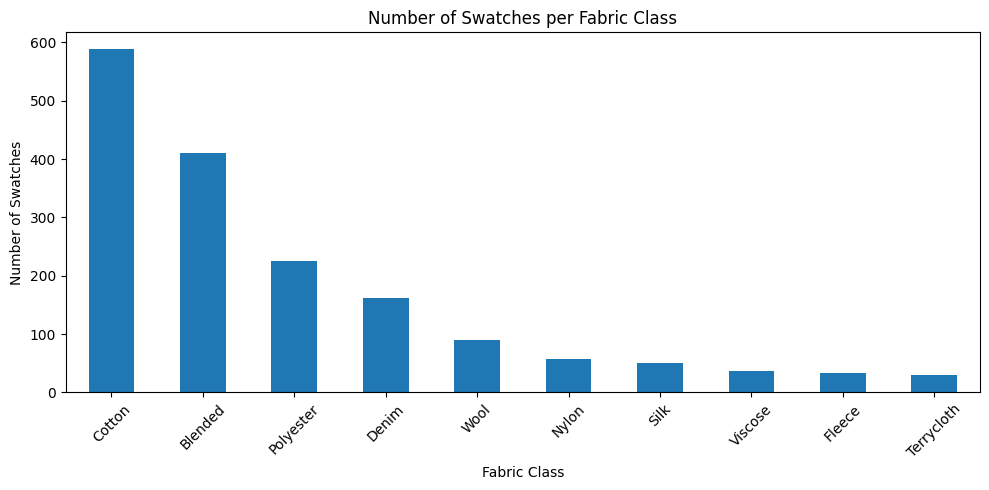

In [14]:
class_counts = swatch_df.groupby("class")["swatch_id"].count().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar")
plt.title("Number of Swatches per Fabric Class")
plt.xlabel("Fabric Class")
plt.ylabel("Number of Swatches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Observation:
- The dataset is imbalanced, with Cotton and Blended containing
- substantially more swatches than classes such as Terrycloth,
- Fleece, and Viscose. To reduce the impact of this imbalance,
- class weights will be computed and used during model training.

In [15]:
def build_class_index(class_names_config):
    """
    Create a consistent mapping between fabric classes and their numeric labels.
    """
    classes = sorted(class_names_config)
    class_to_idx = {c: i for i, c in enumerate(classes)}
    return classes, class_to_idx


CLASS_NAMES, CLASS_TO_IDX = build_class_index(CONFIG["CLASS_NAMES"])
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX

{'Blended': 0,
 'Cotton': 1,
 'Denim': 2,
 'Fleece': 3,
 'Nylon': 4,
 'Polyester': 5,
 'Silk': 6,
 'Terrycloth': 7,
 'Viscose': 8,
 'Wool': 9}

In [16]:
def load_and_preprocess_image(filepath, label, img_size):
    """
    Load an image, resize it, normalize pixel values, and return the image with its label.
    """
    image_bytes = tf.io.read_file(filepath)
    image = tf.image.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])  # Set static image shape
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32)
    return image, label


def dataframe_to_dataset(df, class_to_idx, img_size, batch_size, shuffle, seed):
    """
    Convert an image-level DataFrame into a TensorFlow Dataset. Training data is shuffled, while validation and test data
    remain unchanged for consistent evaluation.

    """
    filepaths = df["filepath"].values
    label_indices = df["class"].map(class_to_idx).values
    labels_onehot = tf.keras.utils.to_categorical(label_indices, num_classes=len(class_to_idx))

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels_onehot))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=seed, reshuffle_each_iteration=True)

    ds = ds.map(lambda fp, lbl: load_and_preprocess_image(fp, lbl, img_size),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = dataframe_to_dataset(train_images, CLASS_TO_IDX, CONFIG["IMG_SIZE"], CONFIG["BATCH_SIZE"], shuffle=True, seed=CONFIG["SEED"])
val_ds   = dataframe_to_dataset(val_images,   CLASS_TO_IDX, CONFIG["IMG_SIZE"], CONFIG["BATCH_SIZE"], shuffle=False, seed=CONFIG["SEED"])
test_ds  = dataframe_to_dataset(test_images,  CLASS_TO_IDX, CONFIG["IMG_SIZE"], CONFIG["BATCH_SIZE"], shuffle=False, seed=CONFIG["SEED"])

for images, labels in train_ds.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)

Batch image shape: (32, 224, 224, 3)
Batch label shape: (32, 10)


In [17]:
# --- Augmentation block ---
# Data augmentation layers applied only during model training.These layers improve model generalization without modifying the original dataset.
# RandomBrightness/RandomContrast matter more than usual for this dataset since swatches were photographed at 4 different lighting angles.
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.06),        # ~±20 degrees
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
], name="data_augmentation")

data_augmentation.build((None, *CONFIG["IMG_SIZE"], 3))
data_augmentation.summary()

Model: "data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
print(f"Training batches   : {len(train_ds)}")
print(f"Validation batches : {len(val_ds)}")
print(f"Testing batches    : {len(test_ds)}")

Training batches   : 148
Validation batches : 32
Testing batches    : 32


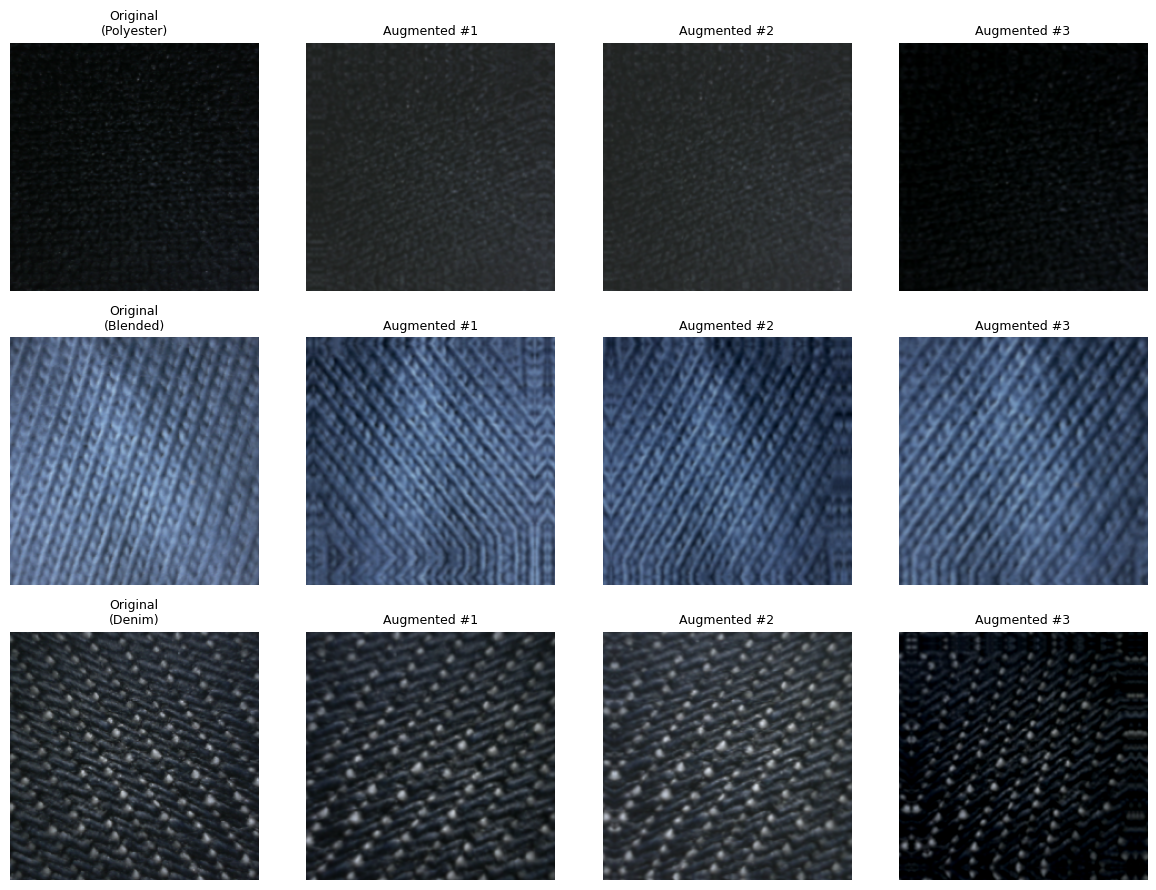

In [19]:
def preview_augmentation(dataset, augmentation_layer, class_names, n_originals=3, n_augmented_per_image=3):
    """
    Display original images alongside augmented versions
    to verify the data augmentation pipeline.
    """
    images, labels = next(iter(dataset.take(1)))
    images, labels = images[:n_originals], labels[:n_originals]

    fig, axes = plt.subplots(
        n_originals, n_augmented_per_image + 1,
        figsize=(3 * (n_augmented_per_image + 1), 3 * n_originals)
    )

    def to_displayable(img_tensor):
        return tf.cast(tf.clip_by_value(img_tensor, 0, 255), tf.uint8).numpy()

    for row in range(n_originals):
        label_name = class_names[int(tf.argmax(labels[row]))]

        axes[row, 0].imshow(to_displayable(images[row]))
        axes[row, 0].set_title(f"Original\n({label_name})", fontsize=9)
        axes[row, 0].axis("off")

        for col in range(1, n_augmented_per_image + 1):
            augmented = augmentation_layer(tf.expand_dims(images[row], 0), training=True)
            axes[row, col].imshow(to_displayable(augmented[0]))
            axes[row, col].set_title(f"Augmented #{col}", fontsize=9)
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()


preview_augmentation(train_ds, data_augmentation, CLASS_NAMES)

In [20]:
def compute_fabric_class_weights(train_df, class_to_idx, dampen_power=0.5, max_weight=3.0):
    """
    Computes balanced class weights, then dampens and caps them.
    """
    labels = train_df["class"].map(class_to_idx).values
    unique_classes = np.unique(labels)

    raw_weights = compute_class_weight(
        class_weight="balanced",
        classes=unique_classes,
        y=labels,
    )

    dampened = raw_weights ** dampen_power
    capped = np.clip(dampened, None, max_weight)

    return {
        int(cls): float(weight)
        for cls, weight in zip(unique_classes, capped)
    }


class_weights = compute_fabric_class_weights(train_images, CLASS_TO_IDX)

idx_to_class = {v: k for k, v in CLASS_TO_IDX.items()}
weight_report = pd.DataFrame([
    {"class": idx_to_class[idx], "weight": w}
    for idx, w in class_weights.items()
]).sort_values("weight", ascending=False)

weight_report

,class,weight
7,Terrycloth,2.368695
3,Fleece,2.263366
8,Viscose,2.128786
6,Silk,1.834783
4,Nylon,1.716282
9,Wool,1.367566
2,Denim,1.021126
5,Polyester,0.863555
0,Blended,0.639343
1,Cotton,0.535424


#### Observation:
- Minority classes receive higher weights, while majority classes receive lower weights. These weights will be used during training to reduce the impact of class imbalance.

In [21]:
def build_fabric_cnn(input_shape, num_classes, augmentation_layer):
    """ Build a CNN model for fabric classification.The model includes data augmentation, normalization, batch normalization, dropout, and global average pooling to improve generalization and reduce overfitting."""
    inputs = keras.Input(shape=input_shape, name="input_image")

    x = augmentation_layer(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    def conv_bn_relu(x, filters):
        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        return x

    # Block 1
    x = conv_bn_relu(x, 32)
    x = conv_bn_relu(x, 32)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

    # Block 2
    x = conv_bn_relu(x, 64)
    x = conv_bn_relu(x, 64)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = conv_bn_relu(x, 128)
    x = conv_bn_relu(x, 128)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Block 4
    x = conv_bn_relu(x, 256)
    x = conv_bn_relu(x, 256)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.35)(x)

    # Block 5
    x = conv_bn_relu(x, 512)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="fabric_probs")(x)

    model = keras.Model(inputs, outputs, name="fabric_classifier_cnn")
    return model


model = build_fabric_cnn(
    input_shape=(*CONFIG["IMG_SIZE"],3),
    num_classes=NUM_CLASSES,
    augmentation_layer=data_augmentation,
)

model.compile(
    optimizer=optimizers.Adam(learning_rate=CONFIG["LEARNING_RATE"]),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_accuracy")],
)

model.summary()
print(f"Total classes : {NUM_CLASSES}")
print(f"Input size    : {CONFIG['IMG_SIZE']}")

Model: "fabric_classifier_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,493,226 (9.51 MB)

 Trainable params: 2,489,770 (9.50 MB)

 Non-trainable params: 3,456 (13.50 KB)

Total classes : 10
Input size    : (224, 224)


In [22]:
def attach_sample_weights(dataset: tf.data.Dataset, class_weight_dict: dict) -> tf.data.Dataset:
    """Attach sample weights to each training sample based on its class. This allows weighted training with one-hot encoded labels.
    """
    # Build a lookup tensor: weight_lookup[class_index] = weight
    num_classes = len(class_weight_dict)
    weight_lookup = tf.constant(
        [class_weight_dict[i] for i in range(num_classes)], dtype=tf.float32
    )
    # Apply class weights only to the training dataset.
    def add_weight(image, label):
        class_idx = tf.argmax(label, axis=-1)
        sample_weight = tf.gather(weight_lookup, class_idx)
        return image, label, sample_weight

    return dataset.map(add_weight, num_parallel_calls=tf.data.AUTOTUNE)


train_ds_weighted = attach_sample_weights(train_ds, class_weights)

for images, labels, sample_weights in train_ds_weighted.take(1):
    print("sample_weights in this batch:", sample_weights.numpy()[:8])

sample_weights in this batch: [1.0211264 0.535424  0.8635554 0.6393432 0.6393432 0.6393432 0.6393432
 0.6393432]


In [23]:
def build_callbacks(model_output_dir: Path, patience_es=12, patience_lr=4):
    """
    - EarlyStopping: stops once val_loss stops improving, restores best weights.
    - ReduceLROnPlateau: halves LR when val_loss plateaus.
    - ModelCheckpoint: saves the single best model (by val_loss) as fabric_classifier.keras.
    - CSVLogger: appends every epoch's metrics to a CSV on disk as training
      progresses — a persistent record independent of the notebook's
      in-memory `history` object, useful if the kernel crashes mid-training
      or you want to compare runs later without re-running anything.
    """
    checkpoint_path = model_output_dir / "fabric_classifier.keras"
    log_path = model_output_dir / "training_log.csv"

    callback_list = [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience_es,
            restore_best_weights=True,
            verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=patience_lr,
            min_lr=1e-6,
            verbose=1,
        ),
        callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
        callbacks.CSVLogger(str(log_path)),
    ]
    return callback_list


training_callbacks = build_callbacks(CONFIG["MODEL_OUTPUT_DIR"])

In [24]:
history = model.fit(
    train_ds_weighted,
    validation_data=val_ds,
    epochs=CONFIG["EPOCHS"],
    callbacks=training_callbacks,
    verbose=1,
)

Epoch 1/40
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.2192 - loss: 2.2476 - top3_accuracy: 0.5176
Epoch 1: val_loss improved from None to 2.09310, saving model to /content/Models/fabric_classifier.keras

Epoch 1: finished saving model to /content/Models/fabric_classifier.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 74s 392ms/step - accuracy: 0.2623 - loss: 2.0892 - top3_accuracy: 0.6111 - val_accuracy: 0.2984 - val_loss: 2.0931 - val_top3_accuracy: 0.6413 - learning_rate: 0.0010
Epoch 2/40
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.2600 - loss: 1.9790 - top3_accuracy: 0.6641
Epoch 2: val_loss did not improve from 2.09310
148/148 ━━━━━━━━━━━━━━━━━━━━ 56s 377ms/step - accuracy: 0.2654 - loss: 1.9909 - top3_accuracy: 0.6548 - val_accuracy: 0.2885 - val_loss: 4.5653 - val_top3_accuracy: 0.6403 - learning_rate: 0.0010
Epoch 3/40
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.2483 - loss: 1.9918 - top3_accuracy: 0.6309
Epoch 3: val_loss improved from 2.09310 to 2.

In [25]:
def load_trained_model(model_path: Path):
    """Loads the saved model. No custom_objects needed — augmentation and
    Rescaling are standard Keras layers, so they deserialize automatically."""
    return keras.models.load_model(model_path)


trained_model = load_trained_model(CONFIG["MODEL_OUTPUT_DIR"] / "fabric_classifier.keras")
trained_model.summary()

Model: "fabric_classifier_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 7,472,768 (28.51 MB)

 Trainable params: 2,489,770 (9.50 MB)

 Non-trainable params: 3,456 (13.50 KB)

 Optimizer params: 4,979,542 (19.00 MB)

In [26]:
def get_predictions(model, dataset):
    """
    Runs the model over an entire tf.data dataset and collects true labels,
    predicted labels, and predicted probabilities — everything downstream
    metrics need. Uses model.predict() batch-by-batch rather than a single
    huge array, so this scales fine even if the test set were much larger.
    """
    y_true, y_pred, y_pred_probs = [], [], []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_pred_probs.append(probs)
        y_true.append(tf.argmax(labels, axis=1).numpy())
        y_pred.append(np.argmax(probs, axis=1))

    return (
        np.concatenate(y_true),
        np.concatenate(y_pred),
        np.concatenate(y_pred_probs),
    )


y_true, y_pred, y_pred_probs = get_predictions(trained_model, test_ds)
print(f"Total test images evaluated: {len(y_true)}")


Total test images evaluated: 1012


In [27]:
def evaluate_model(y_true, y_pred, class_names):
    """Overall + per-class Accuracy, Precision, Recall, F1."""
    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=range(len(class_names)), zero_division=0
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    print(f"Overall Test Accuracy: {accuracy:.4f}\n")
    print(f"Macro    -> Precision: {macro_p:.4f}  Recall: {macro_r:.4f}  F1: {macro_f1:.4f}")
    print(f"Weighted -> Precision: {weighted_p:.4f}  Recall: {weighted_r:.4f}  F1: {weighted_f1:.4f}")

    per_class_df = pd.DataFrame({
        "class": class_names,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "support": support,
    }).sort_values("f1_score")

    return per_class_df


per_class_metrics = evaluate_model(y_true, y_pred, CLASS_NAMES)
per_class_metrics

Overall Test Accuracy: 0.4545

Macro    -> Precision: 0.4227  Recall: 0.4785  F1: 0.4341
Weighted -> Precision: 0.4679  Recall: 0.4545  F1: 0.4544


,class,precision,recall,f1_score,support
9,Wool,0.250000,0.115385,0.157895,52
8,Viscose,0.181818,0.500000,0.266667,24
4,Nylon,0.290323,0.250000,0.268657,36
0,Blended,0.303738,0.266393,0.283843,244
5,Polyester,0.345550,0.485294,0.403670,136
3,Fleece,0.500000,0.500000,0.500000,20
6,Silk,0.514286,0.562500,0.537313,32
1,Cotton,0.607261,0.522727,0.561832,352
7,Terrycloth,0.464286,0.812500,0.590909,16
2,Denim,0.770000,0.770000,0.770000,100


In [28]:
def compute_top3_accuracy(y_true, y_pred_probs, k=3):
    """Matches the TopKCategoricalAccuracy tracked during training, computed
    directly on the test set for the final reported metric."""
    top_k_preds = np.argsort(y_pred_probs, axis=1)[:, -k:]
    correct = [y_true[i] in top_k_preds[i] for i in range(len(y_true))]
    return float(np.mean(correct))


test_top3_accuracy = compute_top3_accuracy(y_true, y_pred_probs)
print(f"Test Top-3 Accuracy: {test_top3_accuracy:.4f}")

Test Top-3 Accuracy: 0.8646


In [29]:
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

              precision    recall  f1-score   support

     Blended       0.30      0.27      0.28       244
      Cotton       0.61      0.52      0.56       352
       Denim       0.77      0.77      0.77       100
      Fleece       0.50      0.50      0.50        20
       Nylon       0.29      0.25      0.27        36
   Polyester       0.35      0.49      0.40       136
        Silk       0.51      0.56      0.54        32
  Terrycloth       0.46      0.81      0.59        16
     Viscose       0.18      0.50      0.27        24
        Wool       0.25      0.12      0.16        52

    accuracy                           0.45      1012
   macro avg       0.42      0.48      0.43      1012
weighted avg       0.47      0.45      0.45      1012



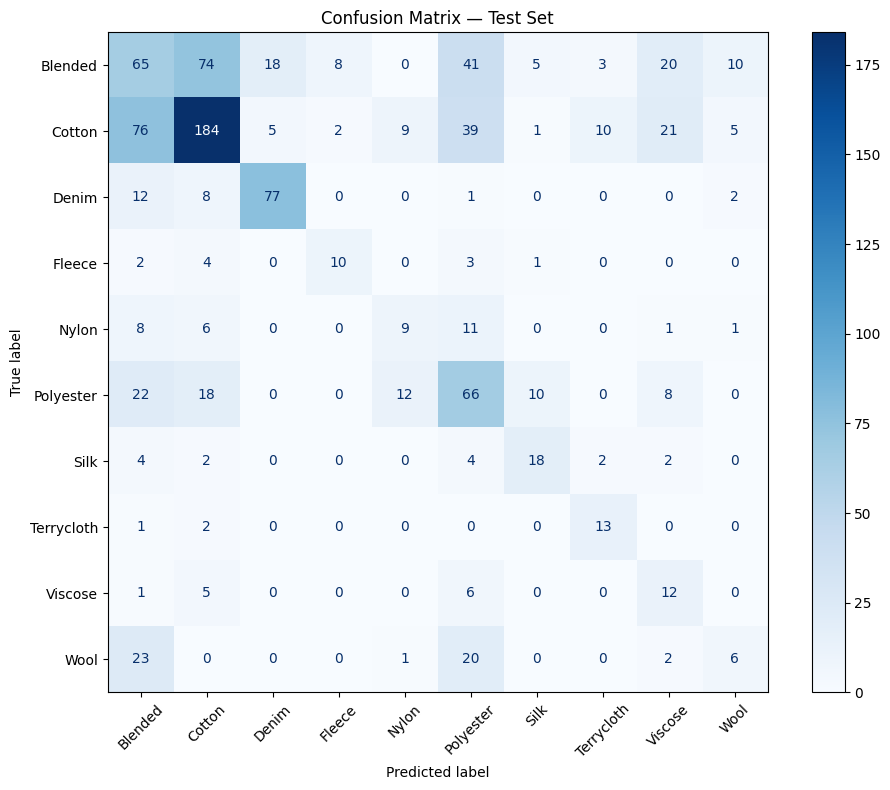

In [30]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))

    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True)
    plt.title("Confusion Matrix — Test Set")
    plt.tight_layout()
    plt.show()

    return cm


cm = plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

In [31]:
def compute_fabric_class_weights(train_df, class_to_idx, dampen_power=0.5, max_weight=3.0):
    """
    Computes 'balanced' weights, then DAMPENS them (dampen_power < 1.0 pulls
    extreme weights toward 1.0, e.g. sqrt with power=0.5) and CAPS the
    maximum. Raw 'balanced' weights had a ~19x spread (5.61 for Terrycloth vs
    0.29 for Cotton), which caused the model to over-predict rare classes at
    the expense of majority-class recall (Cotton/Blended recall ~0.14-0.15
    despite ~0.44-0.62 precision). Dampening narrows that spread while still
    correcting for imbalance.
    """
    labels = train_df["class"].map(class_to_idx).values
    unique_classes = np.unique(labels)

    raw_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=labels)
    dampened = raw_weights ** dampen_power
    capped = np.clip(dampened, None, max_weight)

    return {int(cls): float(w) for cls, w in zip(unique_classes, capped)}


class_weights = compute_fabric_class_weights(train_images, CLASS_TO_IDX)

idx_to_class = {v: k for k, v in CLASS_TO_IDX.items()}
weight_report = pd.DataFrame([
    {"class": idx_to_class[idx], "weight": w} for idx, w in class_weights.items()
]).sort_values("weight", ascending=False)
weight_report

,class,weight
7,Terrycloth,2.368695
3,Fleece,2.263366
8,Viscose,2.128786
6,Silk,1.834783
4,Nylon,1.716282
9,Wool,1.367566
2,Denim,1.021126
5,Polyester,0.863555
0,Blended,0.639343
1,Cotton,0.535424


In [32]:
def save_class_labels(class_to_idx: dict, output_path: Path):
    """
    Saves the definitive class_index -> class_name mapping. This is the SAME
    CLASS_TO_IDX built in Section 3 (sorted alphabetically) and used for
    every training/evaluation step since — never hand-write this mapping
    separately, or it can silently drift out of sync with the model's
    actual output order.
    """
    idx_to_class = {str(idx): name for name, idx in class_to_idx.items()}
    with open(output_path, "w") as f:
        json.dump(idx_to_class, f, indent=2)
    print(f"Saved class labels to {output_path}")
    return idx_to_class


class_labels_path = CONFIG["MODEL_OUTPUT_DIR"] / "class_labels.json"
idx_to_class = save_class_labels(CLASS_TO_IDX, class_labels_path)
idx_to_class

Saved class labels to /content/Models/class_labels.json


{'0': 'Blended',
 '1': 'Cotton',
 '2': 'Denim',
 '3': 'Fleece',
 '4': 'Nylon',
 '5': 'Polyester',
 '6': 'Silk',
 '7': 'Terrycloth',
 '8': 'Viscose',
 '9': 'Wool'}

In [33]:
# Sanity check both required deliverables exist on disk
model_path = CONFIG["MODEL_OUTPUT_DIR"] / "fabric_classifier.keras"
print(f"Model file exists:        {model_path.exists()}  -> {model_path}")
print(f"Class labels file exists: {class_labels_path.exists()}  -> {class_labels_path}")

Model file exists:        True  -> /content/Models/fabric_classifier.keras
Class labels file exists: True  -> /content/Models/class_labels.json


In [34]:
def preprocess_image_for_inference(image_path_or_array, img_size):
    """
    Mirrors load_and_preprocess_image from Section 3, minus label handling,
    for a single image. Accepts either a filepath (str/Path) or an
    already-loaded array (e.g. from an uploaded file in FastAPI) — same
    function works in the notebook and in the eventual API endpoint.
    """
    if isinstance(image_path_or_array, (str, Path)):
        image_bytes = tf.io.read_file(str(image_path_or_array))
        image = tf.image.decode_image(image_bytes, channels=3, expand_animations=False)
    else:
        image = tf.convert_to_tensor(image_path_or_array, dtype=tf.float32)
        if image.shape[-1] != 3:
            raise ValueError("Expected an RGB image with 3 channels.")

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32)      # kept in [0,255]; model's internal
                                             # Rescaling layer handles scaling
    image = tf.expand_dims(image, axis=0)   # add batch dimension
    return image


def predict_fabric(model, image_path_or_array, idx_to_class, img_size, top_k=3):
    """
    Runs inference on a single image and returns a structured result:
    Fabric Type, Confidence Score, and Top-K Predictions.

    Because augmentation + Rescaling live INSIDE the model (Section 5) and
    Keras automatically runs with training=False during model.predict(),
    this function needs no manual augmentation-skipping logic — the exact
    same preprocessing path used at training time (minus the random
    augmentation, which correctly turns off) runs here.
    """
    image = preprocess_image_for_inference(image_path_or_array, img_size)
    probs = model.predict(image, verbose=0)[0]

    top_k_indices = np.argsort(probs)[::-1][:top_k]
    top_k_predictions = [
        {"fabric_type": idx_to_class[str(idx)], "confidence": float(probs[idx])}
        for idx in top_k_indices
    ]

    best_idx = top_k_indices[0]
    return {
        "fabric_type": idx_to_class[str(best_idx)],
        "confidence": float(probs[best_idx]),
        "top_3_predictions": top_k_predictions,
    }

In [35]:
# --- Quick sanity check against a real test-set image ---
sample_row = test_images.sample(1, random_state=CONFIG["SEED"]).iloc[0]

prediction = predict_fabric(trained_model, sample_row["filepath"], idx_to_class, CONFIG["IMG_SIZE"])

print(f"True class: {sample_row['class']}")
print(json.dumps(prediction, indent=2))

True class: Cotton
{
  "fabric_type": "Blended",
  "confidence": 0.6536223292350769,
  "top_3_predictions": [
    {
      "fabric_type": "Blended",
      "confidence": 0.6536223292350769
    },
    {
      "fabric_type": "Cotton",
      "confidence": 0.13513867557048798
    },
    {
      "fabric_type": "Wool",
      "confidence": 0.1018386036157608
    }
  ]
}


In [36]:
import os

print(os.listdir("/content/Models"))

['training_log.csv', 'class_labels.json', 'fabric_classifier.keras']
